## Phase 8 — Analysis & Interpretability

This section analyses the trained models with a focus on interpretability, error behaviour, and generalisation performance. Moving beyond quantitative metrics, it examines how and why the models make decisions by combining attention-based interpretability, structured error categorisation, cross-corpus evaluation (DrugBank vs MedLine), class-specific analysis—particularly for the challenging `int` class—and linguistic feature analysis involving keyword density, sentence structure, and negation. Together, these perspectives provide a concise yet holistic understanding of model behaviour, highlighting both strengths and limitations while supporting the report with interpretable insights and reproducible results.

## Analysis Setup and Environment Configuration

This section sets up the environment for detailed model analysis. It includes imports, reproducibility settings, directory initialisation for storing results, and device selection for computation.

Consistent plotting styles and utility functions are also defined to ensure uniform visualisation across all analysis outputs.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../'))

# Configuration import
from config import *

# Standard libraries
import re, json, pickle, warnings, random

# Data handling
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Deep learning
import torch
import torch.nn as nn

# Utilities
from pathlib import Path
from collections import Counter, defaultdict
from scipy import sparse

# Transformers
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Evaluation metrics
from sklearn.metrics import (
    classification_report,
    f1_score,
    confusion_matrix,
    balanced_accuracy_score,
    matthews_corrcoef,
)

# Suppress warnings
warnings.filterwarnings('ignore')

# Reproducibility
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# Output directories
try:
    ANALYSIS_PLOTS_DIR = Path(str(PLOTS_DIR))   / 'analysis'
    ANALYSIS_METRICS_DIR = Path(str(METRICS_DIR)) / 'analysis'
except NameError:
    ANALYSIS_PLOTS_DIR = Path(str(RESULTS_DIR)) / 'plots'   / 'analysis'
    ANALYSIS_METRICS_DIR = Path(str(RESULTS_DIR)) / 'metrics' / 'analysis'

ANALYSIS_PLOTS_DIR.mkdir(parents=True, exist_ok=True)
ANALYSIS_METRICS_DIR.mkdir(parents=True, exist_ok=True)

# Device selection
DEVICE = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps' if torch.backends.mps.is_available() else
    'cpu'
)

# Class labels
CLASS_NAMES = [ID2LABEL[i] for i in sorted(ID2LABEL)]

# Plot styling
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'font.size': 11,
})

# Utility function to save figures
def save_fig(name):
    path = ANALYSIS_PLOTS_DIR / f'{name}.png'
    plt.savefig(path, dpi=180, bbox_inches='tight', facecolor='white')
    plt.show()

/Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Best Model Selection and Configuration Loading

This step loads the previously computed model comparison results to identify the best-performing models. The selected best transformer model is used for subsequent attention and interpretability analysis.

Relevant paths for model weights and predictions are dynamically resolved to ensure consistency with earlier evaluation outputs.

In [2]:
# Load best model information
best_model_json = Path(str(METRICS_COMPARISON_DIR)) / 'best_model_info.json'

if not best_model_json.exists():
    raise FileNotFoundError(
        f'best_model_info.json not found at {best_model_json}.\n'
        'Run 07_model_comparison.ipynb first to generate it.'
    )

with open(best_model_json) as f:
    best_info = json.load(f)

# Extract best model details
BEST_MODEL = best_info['best_model']
BEST_TRANSFORMER = best_info['best_transformer']
BEST_CLASSICAL = best_info['best_classical']
TRANS_AVAILABLE = best_info['trans_available']

# Map transformer names to directories and prediction files
TRANSFORMER_PATH_MAP = {
    'BioBERT': BIOBERT_DIR,
    'PubMedBERT': PUBMEDBERT_DIR,
    'SciBERT': SCIBERT_DIR,
}

TRANSFORMER_PRED_MAP = {
    'BioBERT': BIOBERT_PREDS_NPY,
    'PubMedBERT': PUBMEDBERT_PREDS_NPY,
    'SciBERT': SCIBERT_PREDS_NPY,
}

# Select transformer for attention analysis
ATTN_MODEL_DIR  = TRANSFORMER_PATH_MAP[BEST_TRANSFORMER]
ATTN_PRED_PATH  = TRANSFORMER_PRED_MAP[BEST_TRANSFORMER]
ATTN_MODEL_NAME = BEST_TRANSFORMER

# Display summary
print(f'Best model overall : {BEST_MODEL}')
print(f'Best transformer : {BEST_TRANSFORMER}  (attention analysis will use this)')
print(f'Best classical : {BEST_CLASSICAL}')
print(f'Transformers present : {TRANS_AVAILABLE}')
print()

Best model overall : PubMedBERT
Best transformer : PubMedBERT  (attention analysis will use this)
Best classical : Linear SVM
Transformers present : ['BioBERT', 'PubMedBERT', 'SciBERT']



## Test Data Loading and Error Analysis Setup

This step loads the processed test dataset along with predictions from the best-performing transformer model. Predictions are mapped back to class labels for interpretability.

The dataset is then partitioned into correctly classified and misclassified samples, enabling targeted error analysis and qualitative inspection of model behaviour.

In [3]:
# Load test data and predictions
print(f'Loading test data and {ATTN_MODEL_NAME} predictions')

test_df = pd.read_csv(TEST_PROCESSED)
y_true  = np.load(Y_TEST_NPY)

print(f'Test rows : {len(test_df):,}')

# Load predictions of best transformer
y_pred_best_trans = np.load(ATTN_PRED_PATH)

# Create prediction column name dynamically
pred_col = ATTN_MODEL_NAME.lower().replace(' ', '_').replace('-', '_') + '_pred'

# Map predictions to labels
test_df['true_label'] = [ID2LABEL[i] for i in y_true]
test_df[pred_col] = [ID2LABEL[i] for i in y_pred_best_trans]

# Identify correct vs incorrect predictions
test_df['model_correct'] = (
    test_df['true_label'] == test_df[pred_col]
)

# Split into correct and error cases
errors  = test_df[~test_df['model_correct']].copy()
correct = test_df[test_df['model_correct']].copy()

# Compute Macro F1
macro_f1 = f1_score(
    y_true,
    y_pred_best_trans,
    average='macro',
    zero_division=0
)

# Summary statistics
print(f'\n{ATTN_MODEL_NAME} accuracy : {test_df["model_correct"].mean()*100:.1f}%')
print(f'Correct : {len(correct):,}')
print(f'Errors : {len(errors):,}  ({len(errors)/len(test_df)*100:.1f}%)')
print(f'Macro F1 : {macro_f1:.4f}')

Loading test data and PubMedBERT predictions
Test rows : 6,657

PubMedBERT accuracy : 92.1%
Correct : 6,130
Errors : 527  (7.9%)
Macro F1 : 0.7222


## Attention Model Loading and Configuration

This step loads the fine-tuned transformer model with attention outputs enabled. The model is configured to return attention weights for interpretability analysis.

Key architectural details such as the number of parameters, layers, and attention heads are reported to contextualise the model’s capacity and complexity.

In [4]:
# Load fine-tuned transformer with attention enabled
print(f'Loading fine-tuned {ATTN_MODEL_NAME} for attention extraction')

ATTN_TOKENISER = AutoTokenizer.from_pretrained(ATTN_MODEL_DIR)

ATTN_MODEL = AutoModelForSequenceClassification.from_pretrained(
    ATTN_MODEL_DIR,
    output_attentions=True,          # Enable attention outputs
    attn_implementation='eager',     # Required for attention extraction
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)

# Set evaluation mode and move to device
ATTN_MODEL.eval()
ATTN_MODEL = ATTN_MODEL.to(DEVICE)

# Model statistics
n_params = sum(p.numel() for p in ATTN_MODEL.parameters())
n_layers = ATTN_MODEL.config.num_hidden_layers
n_heads  = ATTN_MODEL.config.num_attention_heads

print(f'Parameters : {n_params/1e6:.1f}M')
print(f'Attention layers : {n_layers}')
print(f'Attention heads/layer: {n_heads}')

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Loading fine-tuned PubMedBERT for attention extraction
Parameters : 108.2M
Attention layers : 12
Attention heads/layer: 12


## CLS Attention Extraction

This function extracts attention weights from the [CLS] token, which serves as the aggregate representation used for classification in transformer models. The attention weights indicate which tokens the model focuses on when making predictions.

Two modes are supported:
- **last**: uses attention from the final layer
- **mean**: averages attention across all layers for a more global view

The output includes tokens, their corresponding attention weights, and the predicted label, enabling interpretability of model decisions.

In [5]:
def extract_cls_attention(
    text: str,
    model,
    tokeniser,
    max_len: int = 128,
    layer: str = 'last',
):
    # Tokenise input text
    enc = tokeniser(
        text,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='pt',
    )

    input_ids = enc['input_ids'].to(DEVICE)
    attention_mask = enc['attention_mask'].to(DEVICE)

    # Forward pass with attention outputs
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

    all_attentions = outputs.attentions

    # Select attention layer
    if layer == 'last':
        cls_attn = all_attentions[-1][0, :, 0, :]
    elif layer == 'mean':
        stacked = torch.stack([a[0, :, 0, :] for a in all_attentions])
        cls_attn = stacked.mean(dim=0)
    else:
        raise ValueError(f'layer must be "last" or "mean", got: {layer!r}')

    # Average across attention heads
    cls_attn_mean = cls_attn.mean(dim=0).cpu().numpy()

    # Extract valid tokens (remove padding)
    seq_len = int(attention_mask.sum().item())
    tokens = tokeniser.convert_ids_to_tokens(
        input_ids[0, :seq_len].cpu().numpy()
    )

    # Normalise attention weights
    weights = cls_attn_mean[:seq_len]
    weights = weights / weights.sum()

    # Predicted label
    pred_label = ID2LABEL[
        int(np.argmax(outputs.logits[0].cpu().numpy()))
    ]

    return tokens, weights, pred_label


# Quick validation example
sample_text = 'DRUG1 is contraindicated in patients receiving DRUG2 therapy.'

toks, wts, pred = extract_cls_attention(
    sample_text,
    ATTN_MODEL,
    ATTN_TOKENISER,
    layer='last'
)

print(f'Sample sentence : "{sample_text}"')
print(f'Predicted class : {pred}')
print(f'Top-5 attended tokens (last layer):')

# Display top attention tokens
for idx in np.argsort(wts)[-5:][::-1]:
    print(f'[{idx:3d}] {toks[idx]:<20} {wts[idx]:.4f}')

Sample sentence : "DRUG1 is contraindicated in patients receiving DRUG2 therapy."
Predicted class : advise
Top-5 attended tokens (last layer):
[ 10] [SEP]                0.3681
[  9] .                    0.2638
[  3] contraindicated      0.0810
[  2] is                   0.0764
[  7] DRUG2                0.0470


## Sample Selection for Attention Visualisation

This step selects representative correctly classified examples from each class for qualitative attention analysis. Sentences are filtered to a moderate length range to ensure interpretability of attention patterns.

Up to two samples per class are randomly selected, prioritising sentences with 10–30 tokens. This ensures that visualisations remain readable while still capturing meaningful linguistic structure.

In [6]:
# Set random seed for reproducibility
random.seed(RANDOM_STATE)

SELECTED = {}

# Select representative sentences per class
for label in LABEL_ORDER:
    # Filter correctly classified samples for the given class
    pool = (
        test_df[
            (test_df['true_label'] == label) &
            (test_df['model_correct'] == True)
        ]['sentence_masked']
        .dropna()
        .tolist()
    )

    # Prefer medium-length sentences for better interpretability
    pool_short = [s for s in pool if 10 <= len(s.split()) <= 30]
    candidates = pool_short if len(pool_short) >= 2 else pool

    # Select up to 2 samples per class
    n_pick = min(2, len(candidates))
    picked = random.sample(candidates, n_pick)

    SELECTED[label] = picked

    # Display selected samples
    print(f'{label:<12}: {len(pool):4d} correct predictions  | picked {n_pick}')
    for i, s in enumerate(picked):
        print(f'[{i+1}] {s[:90]}{"..." if len(s) > 90 else ""}')
    print()

# Summary
total_selected = sum(len(v) for v in SELECTED.values())
print(f'Total sentences selected for attention visualisation: {total_selected}')

false       : 5406 correct predictions  | picked 2
[1] Inducers of CYP3A4 Isozymes: Cytochrome P450 inducers, such as rifampin, DRUG1, and DRUG2,...
[2] While there is evidence that DRUG1 can inhibit the metabolism of DRUG2 and levonorgestrel,...

effect      :  276 correct predictions  | picked 2
[1] Synergism was also noted when DRUG1 was combined with DRUG2 and amikacin.
[2] Use with Other Central Nervous System Depressants: The depressant effects of DRUG1 are pot...

mechanism   :  230 correct predictions  | picked 2
[1] Absorption of DRUG1 is impaired by antacids containing aluminum, calcium or magnesium, and...
[2] Inducers of CYP3A4 Isozymes: Cytochrome P450 inducers, such as rifampin, carbamazepine, an...

advise      :  181 correct predictions  | picked 2
[1] You cannot take DRUG1 if you have taken a monoamine oxidase inhibitor (MAOI) such as isoca...
[2] If DRUG1    is administered following administration of DRUG2, it should not be given unti...

int         :   37 correct p

## Aggregated Attention Analysis by Class

This step aggregates token-level attention scores across selected examples to identify the most influential words for each class. Tokens are cleaned and filtered to remove special symbols and placeholders.

Attention weights are normalised per class, and the top tokens are ranked based on their relative contribution. This provides insight into what linguistic cues the model relies on for different interaction types.

In [7]:
# Tokens to exclude from analysis
EXCLUDE_TOKENS = {'[cls]', '[sep]', '[pad]', '', 'drug1', 'drug2'}

class_top_tokens = defaultdict(list)

# Collect token-level attention across selected samples
for label in LABEL_ORDER:
    for sent in SELECTED.get(label, []):
        toks, wts, pred = extract_cls_attention(
            sent,
            ATTN_MODEL,
            ATTN_TOKENISER,
            layer='last'
        )

        for tok, w in zip(toks, wts):
            clean = tok.replace('##', '').lower().strip()

            # Filter out irrelevant tokens
            if clean not in EXCLUDE_TOKENS and len(clean) > 2:
                class_top_tokens[label].append((clean, w))

summary_rows = []

# Aggregate and normalise attention per class
for label in LABEL_ORDER:
    tok_agg = defaultdict(float)

    for tok, w in class_top_tokens[label]:
        tok_agg[tok] += w

    total_w = sum(tok_agg.values())

    if total_w > 0:
        tok_agg = {t: v / total_w for t, v in tok_agg.items()}

    # Select top 10 tokens per class
    top10 = sorted(tok_agg.items(), key=lambda x: -x[1])[:10]

    for rank, (tok, w) in enumerate(top10, 1):
        summary_rows.append({
            'Class': label,
            'Rank': rank,
            'Token': tok,
            'Relative Attention': round(w, 5)
        })

# Create summary DataFrame
summary_df = pd.DataFrame(summary_rows)

# Pivot for display
pivot_summary = summary_df.pivot_table(
    index='Rank',
    columns='Class',
    values='Token',
    aggfunc='first'
)[LABEL_ORDER]

# Display results
print('-' * 70)
print(f'  Top 10 Most-Attended Tokens per Class ({ATTN_MODEL_NAME}, last layer)')
print('-' * 70)
print(pivot_summary.to_string())

# Interpretation guide
print()
print('Key expected patterns:')
print('mechanism: CYP/inhibit/metabol/enzyme/clearance tokens')
print('advise: contraindicated/monitor/caution/avoid tokens')
print('int: interact/combination/co-admin tokens')
print('false: not/no/without (negation) prominently')

# Save results
summary_df.to_csv(
    ANALYSIS_METRICS_DIR / 'attention_top_tokens_per_class.csv',
    index=False
)

----------------------------------------------------------------------
  Top 10 Most-Attended Tokens per Class (PubMedBERT, last layer)
----------------------------------------------------------------------
Class       false     effect      mechanism          advise       int
Rank                                                                 
1       midazolam       when     absorption            cann  interact
2      metabolism        was     metabolism            take      with
3             and       with         caused             you   adrenal
4            that        and            and  administration       can
5         inducer    depress       impaired          should       and
6           there        are        studies            from       may
7             max  synergism      decreased        recovery  decrease
8        rifampin    effects            max       following  function
9          cyp3a4        the  carbamazepine             not   causing
10          adult      

## Domain-Specific Attention Analysis

This analysis quantifies how much attention the model allocates to domain-relevant tokens for each interaction type. Domain tokens are defined using pharmacological and linguistic cues specific to each class.

The percentage reflects the proportion of total [CLS] attention focused on meaningful domain signals, providing insight into whether the model relies on clinically relevant language for its predictions.

false       : 3.9% attention on domain tokens
effect      : 0.0% attention on domain tokens
mechanism   : 15.8% attention on domain tokens
advise      : 0.0% attention on domain tokens
int         : 5.1% attention on domain tokens


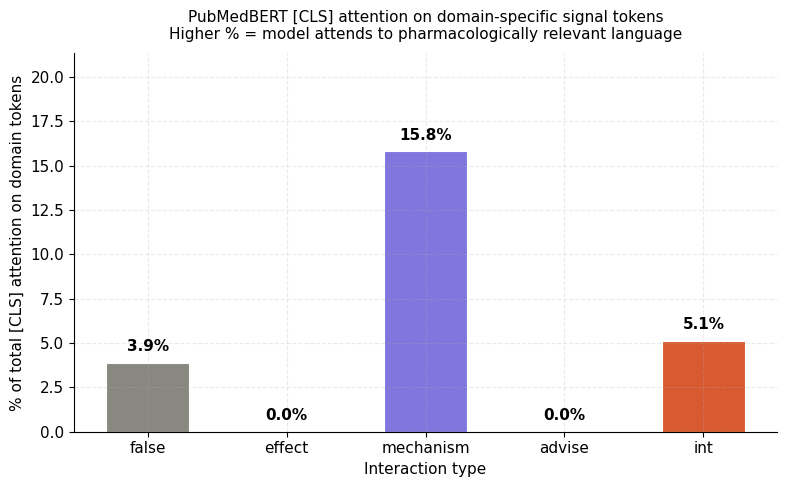

In [8]:
# Define domain-specific token patterns
DOMAIN_TOKENS = {
    'mechanism': {'inhibit', 'induc', 'metabol', 'cyp', 'clearance', 'enzyme', 'absorpt', 'half'},
    'effect': {'bleeding', 'toxic', 'adverse', 'risk', 'prolonged', 'sedation', 'elevated'},
    'advise': {'contraindicated', 'avoid', 'caution', 'monitor', 'warning', 'recommend', 'concomitant'},
    'int': {'interact', 'interaction', 'combination', 'co-admin', 'combined'},
    'false': {'not', 'no', 'without', 'neither', 'nor', 'never', 'none'},
}

domain_pct_data = []

# Compute attention percentage on domain tokens per class
for label in LABEL_ORDER:
    all_domain_w = 0.0
    all_total_w = 0.0

    for sent in SELECTED.get(label, []):
        toks, wts, pred = extract_cls_attention(
            sent,
            ATTN_MODEL,
            ATTN_TOKENISER,
            layer='last'
        )

        for tok, w in zip(toks, wts):
            clean = tok.replace('##', '').lower().strip()

            all_total_w += w

            # Check if token matches domain-specific patterns
            if any(d in clean for d in DOMAIN_TOKENS.get(label, set())):
                all_domain_w += w

    pct = (all_domain_w / all_total_w * 100) if all_total_w > 0 else 0

    domain_pct_data.append({
        'Class': label,
        'Domain token attention %': round(pct, 1)
    })

    print(f'{label:<12}: {pct:.1f}% attention on domain tokens')

# Create DataFrame
domain_df = pd.DataFrame(domain_pct_data)

# Plot results
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    domain_df['Class'],
    domain_df['Domain token attention %'],
    color=[LABEL_COLOURS[l] for l in LABEL_ORDER],
    edgecolor='white',
    width=0.6,
    linewidth=0.8
)

# Annotate bars
for bar, row in zip(bars, domain_df.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{row._2:.1f}%',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Plot formatting
ax.set_title(
    f'{ATTN_MODEL_NAME} [CLS] attention on domain-specific signal tokens\n'
    'Higher % = model attends to pharmacologically relevant language',
    fontsize=11,
    pad=10
)

ax.set_xlabel('Interaction type')
ax.set_ylabel('% of total [CLS] attention on domain tokens')

ax.set_ylim(0, max(domain_df['Domain token attention %']) * 1.35)

plt.tight_layout()
save_fig('domain_token_attention_pct')

# Save results
domain_df.to_csv(
    ANALYSIS_METRICS_DIR / 'domain_token_attention_pct.csv',
    index=False
)

## Error Categorisation Analysis

This step classifies model errors into interpretable categories based on linguistic patterns and prediction behaviour. Each error is assigned a category reflecting its likely cause, such as negation handling, long-range dependencies, or semantic ambiguity.

This structured analysis helps diagnose systematic weaknesses in the model and provides actionable insights for improvement.

In [9]:
# Define negation terms
NEGATION_WORDS = {'not', 'no', 'without', 'neither', 'nor', 'never', 'none'}

# Categorise errors based on linguistic and prediction patterns
def categorise_error(row) -> str:
    true = row['true_label']
    pred = row[pred_col]
    cleaned = str(row.get('sentence_cleaned', '')).lower()
    words = set(cleaned.split())

    # Negation misinterpretation
    if bool(words & NEGATION_WORDS) and pred != 'false' and true == 'false':
        return 'NEG — Negation reversal'

    # Long-range dependency issue
    wb = row.get('words_between', -1)
    if isinstance(wb, (int, float)) and wb > 15:
        return 'LRD — Long-range dependency'

    # Generic interaction confusion
    if true == 'int' and pred in {'effect', 'mechanism', 'advise'}:
        return 'GEN — Generic interaction language'

    # Mechanism vs effect ambiguity
    if (true == 'mechanism' and pred == 'effect') or (true == 'effect' and pred == 'mechanism'):
        return 'AMB2 — Mechanism/effect ambiguity'

    # Ambiguous drug classes
    d1_type = str(row.get('drug1_type', '')).lower()
    d2_type = str(row.get('drug2_type', '')).lower()
    if 'group' in d1_type or 'group' in d2_type:
        return 'AMB — Ambiguous drug class'

    # False positive due to noisy corpus
    if true == 'false' and pred in {'effect', 'mechanism', 'advise', 'int'}:
        return 'NOI — Corpus noise (false → interaction)'

    # Dangerous miss (false negative)
    if true in {'effect', 'mechanism', 'advise', 'int'} and pred == 'false':
        return 'DNG — Dangerous miss (interaction → false)'

    # Other errors
    return 'OTH — Other'


# Apply categorisation
errors['error_category'] = errors.apply(categorise_error, axis=1)

# Compute counts and percentages
cat_counts = errors['error_category'].value_counts()
cat_pct = (cat_counts / len(errors) * 100).round(1)

# Display results
print('-' * 65)
print(f'  {ATTN_MODEL_NAME} Error Categorisation  (n={len(errors):,} errors)')
print('-' * 65)

cat_df = pd.DataFrame({
    'Count': cat_counts,
    'Pct %': cat_pct
})

print(cat_df.to_string())

print(f'\nTotal categorised: {len(errors):,}')

# Save results
cat_df.to_csv(ANALYSIS_METRICS_DIR / 'error_categories.csv')

-----------------------------------------------------------------
  PubMedBERT Error Categorisation  (n=527 errors)
-----------------------------------------------------------------
                                            Count  Pct %
error_category                                          
AMB — Ambiguous drug class                    169   32.1
NOI — Corpus noise (false → interaction)      131   24.9
DNG — Dangerous miss (interaction → false)    128   24.3
GEN — Generic interaction language             41    7.8
NEG — Negation reversal                        36    6.8
OTH — Other                                    16    3.0
AMB2 — Mechanism/effect ambiguity               6    1.1

Total categorised: 527


## Error Distribution by Category

This plot shows the overall distribution of error types made by the model. It highlights the most frequent failure modes, providing insight into dominant weaknesses such as negation handling, ambiguity, or generic interaction confusion.

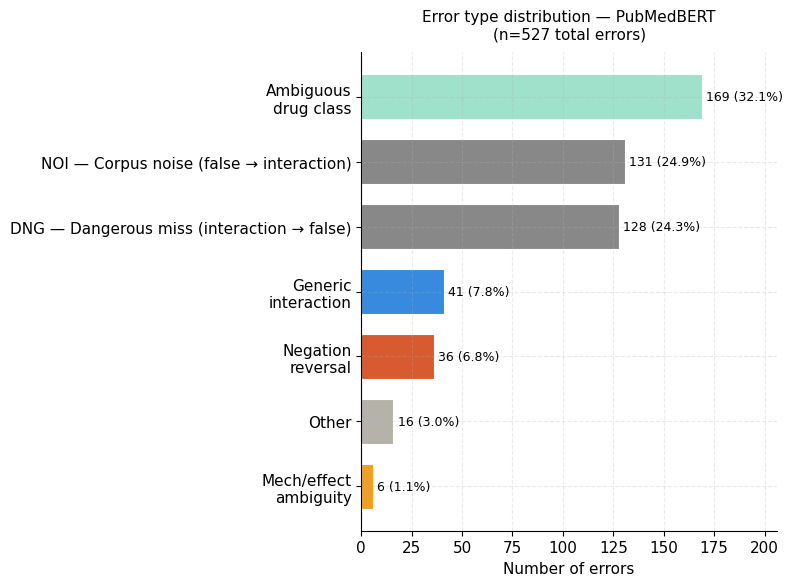

In [10]:
# Prepare labels and colours
SHORT_LABELS = {
    'NEG — Negation reversal': 'Negation\nreversal',
    'LRD — Long-range dependency': 'Long-range\ndependency',
    'GEN — Generic interaction language': 'Generic\ninteraction',
    'AMB2 — Mechanism/effect ambiguity': 'Mech/effect\nambiguity',
    'AMB — Ambiguous drug class': 'Ambiguous\ndrug class',
    'NOI — Corpus noise (false to interaction)': 'Corpus\nnoise',
    'DNG — Dangerous miss (interaction to false)': 'Dangerous\nmiss',
    'OTH — Other': 'Other',
}

cat_colours = {
    'NEG — Negation reversal': '#D85A30',
    'LRD — Long-range dependency': '#7F77DD',
    'GEN — Generic interaction language': '#378ADD',
    'AMB2 — Mechanism/effect ambiguity': '#EF9F27',
    'AMB — Ambiguous drug class': '#9FE1CB',
    'NOI — Corpus noise (false to interaction)': '#FAC775',
    'DNG — Dangerous miss (interaction to false)': '#E05C8A',
    'OTH — Other': '#B4B2A9',
}

### Error Distribution by Category
# error distribution
fig, ax = plt.subplots(figsize=(8, 6))

cats_ordered = cat_counts.index.tolist()
short_cats = [SHORT_LABELS.get(c, c) for c in cats_ordered]
colours_bar = [cat_colours.get(c, '#888') for c in cats_ordered]

bars = ax.barh(
    short_cats[::-1],
    cat_counts.values[::-1],
    color=colours_bar[::-1],
    edgecolor='white',
    linewidth=0.8,
    height=0.7
)

# Annotate bars
for bar, val, pct in zip(bars, cat_counts.values[::-1], cat_pct.values[::-1]):
    ax.text(
        bar.get_width() + 2,
        bar.get_y() + bar.get_height() / 2,
        f'{val} ({pct:.1f}%)',
        va='center',
        fontsize=9
    )

ax.set_title(
    f'Error type distribution — {ATTN_MODEL_NAME}\n(n={len(errors):,} total errors)',
    fontsize=11,
    pad=10
)
ax.set_xlabel('Number of errors')
ax.margins(x=0.22)

plt.tight_layout()
save_fig('error_distribution')

## Error Breakdown per Class

This stacked bar chart shows how different error types are distributed within each true class. It reveals class-specific weaknesses, such as whether certain classes are more prone to ambiguity, negation errors, or dangerous misclassifications.

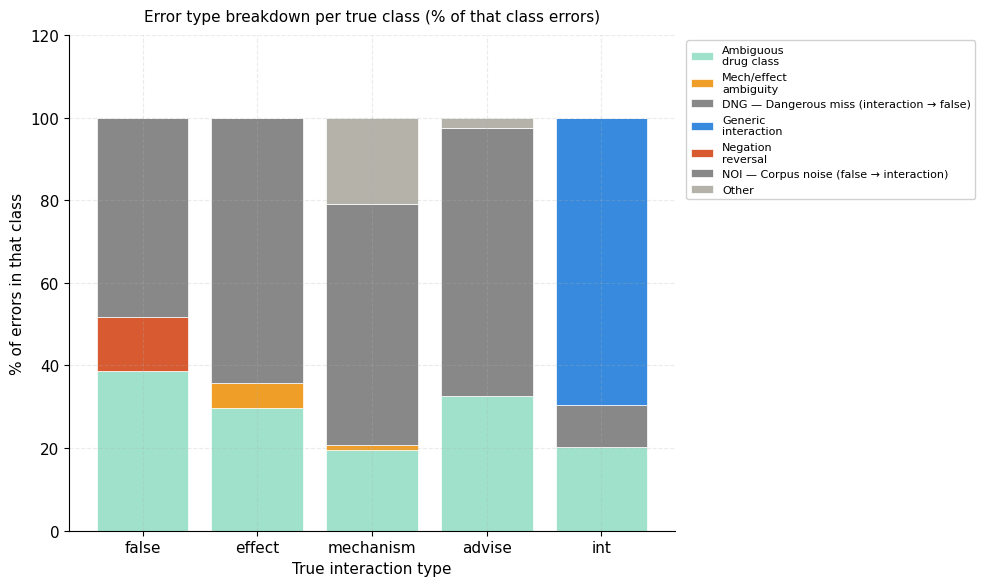

In [11]:
# Class-wise error breakdown
fig, ax = plt.subplots(figsize=(10, 6))

class_cat_pivot = pd.crosstab(errors['true_label'], errors['error_category'])
class_cat_pivot = class_cat_pivot.reindex(
    [l for l in LABEL_ORDER if l in class_cat_pivot.index]
)

class_cat_pct = class_cat_pivot.div(class_cat_pivot.sum(axis=1), axis=0) * 100

bottom = np.zeros(len(class_cat_pct))

for col in class_cat_pct.columns:
    vals = class_cat_pct[col].fillna(0).values
    colour = cat_colours.get(col, '#888')

    ax.bar(
        class_cat_pct.index,
        vals,
        bottom=bottom,
        label=SHORT_LABELS.get(col, col),
        color=colour,
        edgecolor='white',
        linewidth=0.5
    )

    bottom += vals

ax.set_title(
    'Error type breakdown per true class (% of that class errors)',
    fontsize=11,
    pad=10
)
ax.set_xlabel('True interaction type')
ax.set_ylabel('% of errors in that class')
ax.set_ylim(0, 120)

ax.legend(
    fontsize=8,
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    framealpha=0.9
)

plt.tight_layout()
save_fig('error_breakdown_per_class')

## Qualitative Error Examples

This section presents representative examples for each error category to provide qualitative insight into model failures. For each category, one or two examples are shown along with their true and predicted labels.

Additional contextual signals (e.g., negation words, drug types, or distance between entities) are displayed where relevant to better understand the source of error.

In [12]:
# Display representative error examples per category

print(f'Error Examples per Category — {ATTN_MODEL_NAME} (1–2 per type)')

for cat in cat_counts.index:
    subset = errors[errors['error_category'] == cat]

    print(f'\n{cat}  (n={len(subset):,})')
    print('-' * 60)

    # Show up to 2 examples per category
    for _, row in subset.head(2).iterrows():
        orig  = str(row.get('sentence_original', row.get('sentence_masked', '')))
        clean = str(row.get('sentence_cleaned', ''))

        print(f'  True: {row["true_label"]:<12}  Pred: {row[pred_col]:<12}')
        print(f'  Sentence : {orig[:120]}')

        # Category-specific diagnostics
        if 'NEG' in cat:
            neg_found = [w for w in NEGATION_WORDS if w in clean.split()]
            print(f'Negation words found: {neg_found}')

        elif 'LRD' in cat:
            print(f'Words between drugs: {row.get("words_between", "?")}')

        elif 'AMB' in cat and 'AMB2' not in cat:
            print(f'Drug types: {row.get("drug1_type","?")} + {row.get("drug2_type","?")}')

        print()

Error Examples per Category — PubMedBERT (1–2 per type)

AMB — Ambiguous drug class  (n=169)
------------------------------------------------------------
  True: false         Pred: advise      
  Sentence : When ZETIA is administered with an HMG-CoA reductase inhibitor in a woman of childbearing potential, refer to the pregna
Drug types: brand + group

  True: false         Pred: advise      
  Sentence : When DIFLUCAN is used concomitantly with these or other sulfonylurea oral hypoglycemic agents, blood glucose concentrati
Drug types: brand + group


NOI — Corpus noise (false → interaction)  (n=131)
------------------------------------------------------------
  True: false         Pred: mechanism   
  Sentence : In a study of 11 HIV-infected patients receiving methadone-maintenance therapy (40 mg and 90 mg daily) with 600 mg of ZI

  True: false         Pred: mechanism   
  Sentence : Cholestyramine: Concomitant cholestyramine administration decreased the mean AUC of total ezetimibe 

## Loading Model Predictions for Generalisation Analysis

This step aggregates predictions from all model families, including classical machine learning models, rule-based methods, and transformer-based models. This unified setup enables consistent evaluation of generalisation behaviour across different modelling approaches.

Special handling is applied to Naive Bayes inputs to ensure compatibility with feature constraints, while rule-based predictions are reconstructed using predefined keyword heuristics.

In [13]:
# Load all model predictions for generalisation analysis
print('Loading all model predictions for generalisation analysis')

# Load test features
X_test = sparse.load_npz(TEST_FEATURES_NPZ)

# Load label encoder
with open(LABEL_ENCODER_PKL, 'rb') as f:
    encoder = pickle.load(f)

all_preds = {}

# Load classical ML model predictions
for fname, name in [
    ('naive_bayes.pkl', 'Naive Bayes'),
    ('logistic_regression.pkl', 'Logistic Regression'),
    ('random_forest.pkl', 'Random Forest'),
    ('svm.pkl', 'Linear SVM'),
]:
    fpath = os.path.join(str(FEATURES_ARTEFACTS_DIR), fname)

    if os.path.exists(fpath):
        with open(fpath, 'rb') as f:
            m = pickle.load(f)

        # Special preprocessing for Naive Bayes
        if 'naive' in fname:
            X_nb = np.clip(X_test.toarray().astype(np.float32), 0, None)
            wb_idx = X_test.shape[1] - 24 + 3
            X_nb[:, wb_idx] = np.clip(X_nb[:, wb_idx], 0, None)
            all_preds[name] = m.predict(X_nb)
        else:
            all_preds[name] = m.predict(X_test)

        print(f'{name:<22} loaded')
    else:
        print(f'{name:<22} MISSING — skipped')

# Rule-based baseline
RULES = {
    'mechanism': {'inhibit','induce','metabolis','metaboliz','cyp','enzyme',
                  'absorption','clearance','half-life','bioavailability','pharmacokinetic'},
    'effect': {'bleeding','toxicity','sedation','hypotension','bradycardia',
               'adverse','side effect','prolonged','elevated'},
    'advise': {'contraindicated','avoid','caution','recommend','monitor',
               'warning','should not','do not','concomitant'},
    'int': {'interact','interaction','combined with','co-administration','combination'},
}

def rule_predict(sentences):
    preds = []
    for s in sentences:
        sl = str(s).lower()
        pred = 'false'

        for lbl in ['mechanism', 'effect', 'advise', 'int']:
            if any(kw in sl for kw in RULES[lbl]):
                pred = lbl
                break

        preds.append(pred)

    return preds

# Generate rule-based predictions
all_preds['Rule-based'] = encoder.transform(
    rule_predict(test_df['sentence_cleaned'])
)

# Load transformer predictions
for trans_name, pred_path in [
    ('BioBERT', BIOBERT_PREDS_NPY),
    ('PubMedBERT', PUBMEDBERT_PREDS_NPY),
    ('SciBERT', SCIBERT_PREDS_NPY),
]:
    if trans_name in TRANS_AVAILABLE and os.path.exists(pred_path):
        all_preds[trans_name] = np.load(pred_path)
        print(f'{trans_name:<22} loaded')

Loading all model predictions for generalisation analysis
Naive Bayes            loaded
Logistic Regression    loaded
Random Forest          loaded
Linear SVM             loaded
BioBERT                loaded
PubMedBERT             loaded
SciBERT                loaded


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


## Generalisation Across Corpus Sources

This analysis evaluates how model performance varies across different data sources, specifically DrugBank and MedLine. By computing Macro F1 separately for each source, we assess the robustness and generalisation ability of each model.

Performance differences between transformer, classical, and rule-based approaches are also quantified to understand how well models transfer across domains.

In [14]:
# Evaluate generalisation across different corpus sources

# Select models for analysis
MODELS_FOR_ANALYSIS = [
    m for m in ['Rule-based', BEST_CLASSICAL] + TRANS_AVAILABLE
    if m in all_preds
]

source_results = []

# Evaluate per source
for source in ['DrugBank', 'MedLine']:
    mask = test_df['corpus_source'].str.strip() == source
    source_idx = np.where(mask.values)[0]

    y_true_source = y_true[source_idx]
    n_rows = len(source_idx)

    for model_name in MODELS_FOR_ANALYSIS:
        if model_name not in all_preds:
            continue

        preds_source = all_preds[model_name][source_idx]

        # Compute Macro F1
        macro_f1 = f1_score(
            y_true_source,
            preds_source,
            average='macro',
            zero_division=0
        )

        # Detailed classification report
        rep = classification_report(
            y_true_source,
            preds_source,
            target_names=CLASS_NAMES,
            output_dict=True,
            zero_division=0
        )

        row = {
            'Model': model_name,
            'Source': source,
            'N': n_rows,
            'Macro F1': round(macro_f1, 4)
        }

        # Add per-class F1
        for lbl in LABEL_ORDER:
            if lbl in rep:
                row[f'F1({lbl})'] = round(rep[lbl]['f1-score'], 4)

        source_results.append(row)

# Create DataFrame
source_df = pd.DataFrame(source_results)

# Pivot for display
pivot = source_df.pivot_table(
    index='Model',
    columns='Source',
    values='Macro F1'
)

# Display results
print('-' * 60)
print('  Macro F1 by Corpus Source')
print('-' * 60)

print(pivot.reindex(MODELS_FOR_ANALYSIS).round(4).to_string())
print()

# Compare key models
for source in ['DrugBank', 'MedLine']:
    sub = source_df[source_df['Source'] == source].set_index('Model')

    if BEST_TRANSFORMER in sub.index and BEST_CLASSICAL in sub.index:
        delta = sub.loc[BEST_TRANSFORMER, 'Macro F1'] - sub.loc[BEST_CLASSICAL, 'Macro F1']
        print(f'{source}: {BEST_TRANSFORMER} vs {BEST_CLASSICAL}  Δ Macro F1 = {delta:+.4f}')

    if 'Rule-based' in sub.index and BEST_TRANSFORMER in sub.index:
        delta_rb = sub.loc[BEST_TRANSFORMER, 'Macro F1'] - sub.loc['Rule-based', 'Macro F1']
        print(f'{source}: {BEST_TRANSFORMER} vs Rule-based    Δ Macro F1 = {delta_rb:+.4f}')

    print()

# Save results
source_df.to_csv(
    ANALYSIS_METRICS_DIR / 'generalisation_by_source.csv',
    index=False
)

------------------------------------------------------------
  Macro F1 by Corpus Source
------------------------------------------------------------
Source      DrugBank  MedLine
Model                        
Rule-based    0.1896   0.2149
Linear SVM    0.5497   0.4627
BioBERT       0.6874   0.5332
PubMedBERT    0.7402   0.4932
SciBERT       0.7361   0.4776

DrugBank: PubMedBERT vs Linear SVM  Δ Macro F1 = +0.1905
DrugBank: PubMedBERT vs Rule-based    Δ Macro F1 = +0.5506

MedLine: PubMedBERT vs Linear SVM  Δ Macro F1 = +0.0305
MedLine: PubMedBERT vs Rule-based    Δ Macro F1 = +0.2783



## Generalisation Visualisation: DrugBank vs MedLine

This figure compares model performance across two distinct corpus sources using Macro F1. The left plot shows absolute performance per model, while the right plot highlights the performance gain of transformer models relative to the best classical baseline.

This analysis reveals domain transfer behaviour and whether transformer models provide consistent improvements across different biomedical text sources.

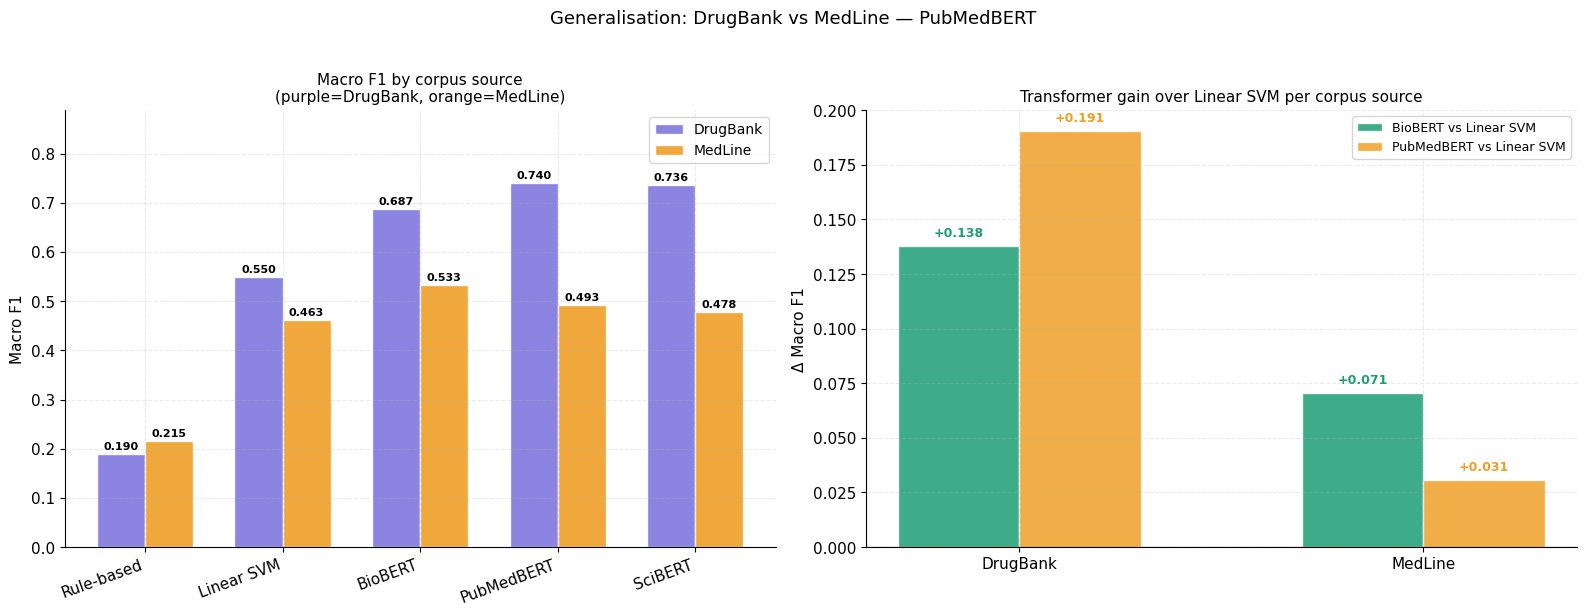

In [15]:
# Visualise generalisation across DrugBank and MedLine
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

n_models = len(MODELS_FOR_ANALYSIS)
x = np.arange(n_models)
w = 0.35

db_f1s, ml_f1s = [], []

# Collect Macro F1 scores
for m in MODELS_FOR_ANALYSIS:
    sub = source_df[source_df['Model'] == m]

    db_val = sub[sub['Source'] == 'DrugBank']['Macro F1'].values
    ml_val = sub[sub['Source'] == 'MedLine']['Macro F1'].values

    db_f1s.append(float(db_val[0]) if len(db_val) else 0)
    ml_f1s.append(float(ml_val[0]) if len(ml_val) else 0)

# Left Plot: Absolute performance
b1 = axes[0].bar(
    x - w/2,
    db_f1s,
    w,
    label='DrugBank',
    color='#7F77DD',
    edgecolor='white',
    alpha=0.9
)

b2 = axes[0].bar(
    x + w/2,
    ml_f1s,
    w,
    label='MedLine',
    color='#EF9F27',
    edgecolor='white',
    alpha=0.9
)

# Annotate values
for bar, val in zip(list(b1) + list(b2), db_f1s + ml_f1s):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{val:.3f}',
        ha='center',
        va='bottom',
        fontsize=8,
        fontweight='bold'
    )

axes[0].set_xticks(x)
axes[0].set_xticklabels(MODELS_FOR_ANALYSIS, rotation=20, ha='right')
axes[0].set_title('Macro F1 by corpus source\n(purple=DrugBank, orange=MedLine)', fontsize=11)
axes[0].set_ylabel('Macro F1')
axes[0].legend(fontsize=10)
axes[0].set_ylim(0, max(db_f1s + ml_f1s) * 1.2)

# Right Plot: Transformer gains
trans_in_analysis = [m for m in TRANS_AVAILABLE if m in MODELS_FOR_ANALYSIS]
clf_idx = MODELS_FOR_ANALYSIS.index(BEST_CLASSICAL) if BEST_CLASSICAL in MODELS_FOR_ANALYSIS else None

if len(trans_in_analysis) >= 1 and clf_idx is not None:
    x2 = np.arange(2)
    w2 = 0.3

    ref_db = db_f1s[clf_idx]
    ref_ml = ml_f1s[clf_idx]

    for k, trans in enumerate(trans_in_analysis[:2]):
        t_idx = MODELS_FOR_ANALYSIS.index(trans)

        delta_db = db_f1s[t_idx] - ref_db
        delta_ml = ml_f1s[t_idx] - ref_ml

        colour = MODEL_COLOURS.get(trans, '#888')
        offset = (k - len(trans_in_analysis[:2]) / 2 + 0.5) * w2

        bars_d = axes[1].bar(
            x2 + offset,
            [delta_db, delta_ml],
            w2,
            label=f'{trans} vs {BEST_CLASSICAL}',
            color=colour,
            edgecolor='white',
            alpha=0.85
        )

        # Annotate deltas
        for xi, val in enumerate([delta_db, delta_ml]):
            axes[1].text(
                xi + offset,
                val + 0.003,
                f'{val:+.3f}',
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold',
                color=colour
            )

    axes[1].axhline(0, color='black', linewidth=0.8)
    axes[1].set_xticks(x2)
    axes[1].set_xticklabels(['DrugBank', 'MedLine'])
    axes[1].set_title(f'Transformer gain over {BEST_CLASSICAL} per corpus source', fontsize=11)
    axes[1].set_ylabel('Δ Macro F1')
    axes[1].legend(fontsize=9)

else:
    axes[1].text(
        0.5, 0.5,
        'Insufficient data for delta plot',
        ha='center',
        va='center',
        transform=axes[1].transAxes
    )
    axes[1].axis('off')

# Overall title
plt.suptitle(
    f'Generalisation: DrugBank vs MedLine — {ATTN_MODEL_NAME}',
    fontsize=13,
    y=1.02
)

plt.tight_layout()
save_fig('generalisation_drugbank_vs_medline')

## Performance on Interaction vs Non-Interaction Classes

This section analyses model performance specifically on the *interaction (int)* class compared to all other classes. It reports class-wise accuracy for interaction samples and examines how often these are misclassified into other categories.

Additionally, per-class F1 scores are presented to provide a complete view of model behaviour across all interaction types.

In [16]:
# Split test set into interaction and non-interaction samples
int_test = test_df[test_df['true_label'] == 'int'].copy()
non_int_test = test_df[test_df['true_label'] != 'int'].copy()

print(f'int class test samples : {len(int_test):,}')
print(f'Non-int test samples : {len(non_int_test):,}')

# Analyse predictions for interaction class
print(f'\n{ATTN_MODEL_NAME} on int class:')

int_preds = test_df.loc[test_df['true_label'] == 'int', pred_col]

# Accuracy on interaction class
correct_int = (int_preds == "int").sum()
print(f'Correct : {correct_int} / {len(int_preds)} ({(correct_int / len(int_preds)) * 100:.1f}%)')

# Distribution of predicted labels
print(' Predicted as:')
for cls, cnt in int_preds.value_counts().items():
    print(f'{cls:<12} {cnt:3d}  ({cnt/len(int_preds)*100:.1f}%)')

# Overall classification report
rep = classification_report(
    y_true,
    y_pred_best_trans,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

# Per-class F1 scores
print(f'\n{ATTN_MODEL_NAME} F1 per class:')

for lbl in LABEL_ORDER:
    f1 = rep.get(lbl, {}).get('f1-score', 0)
    support = rep.get(lbl, {}).get('support', 0)

    print(f'{lbl:<12} F1={f1:.4f} support={int(support)}')

int class test samples : 96
Non-int test samples : 6,561

PubMedBERT on int class:
Correct : 37 / 96 (38.5%)
 Predicted as:
effect        38  (39.6%)
int           37  (38.5%)
false         18  (18.8%)
mechanism      3  (3.1%)

PubMedBERT F1 per class:
false        F1=0.9594 support=5678
effect       F1=0.7282 support=360
mechanism    F1=0.7099 support=302
advise       F1=0.7621 support=221
int          F1=0.4512 support=96


## Why is the `int` Class Hard? Multi-Factor Diagnostic Analysis

This multi-panel figure investigates why the *interaction (int)* class is consistently the most challenging to model. It combines lexical, structural, and performance-based signals to identify failure modes.

- **Keyword density (top-left):** Measures how explicitly each class expresses domain-specific signals. Lower density in `int` suggests weaker lexical cues.
- **Sentence length (top-middle):** Captures contextual complexity; longer sentences often require modelling long-range dependencies.
- **Prediction distribution (top-right):** Shows how `int` samples are misclassified, indicating confusion with other classes.
- **F1 scores (bottom-left):** Highlights class-wise performance gaps, confirming whether `int` is the weakest class.
- **Negation rate (bottom-middle):** Identifies whether negation contributes to ambiguity.
- **Class support (bottom-right):** Examines imbalance effects using log-scale counts.

Together, these panels provide a comprehensive explanation of *why `int` is structurally harder*: weaker lexical anchors, higher semantic overlap, and ambiguous phrasing.

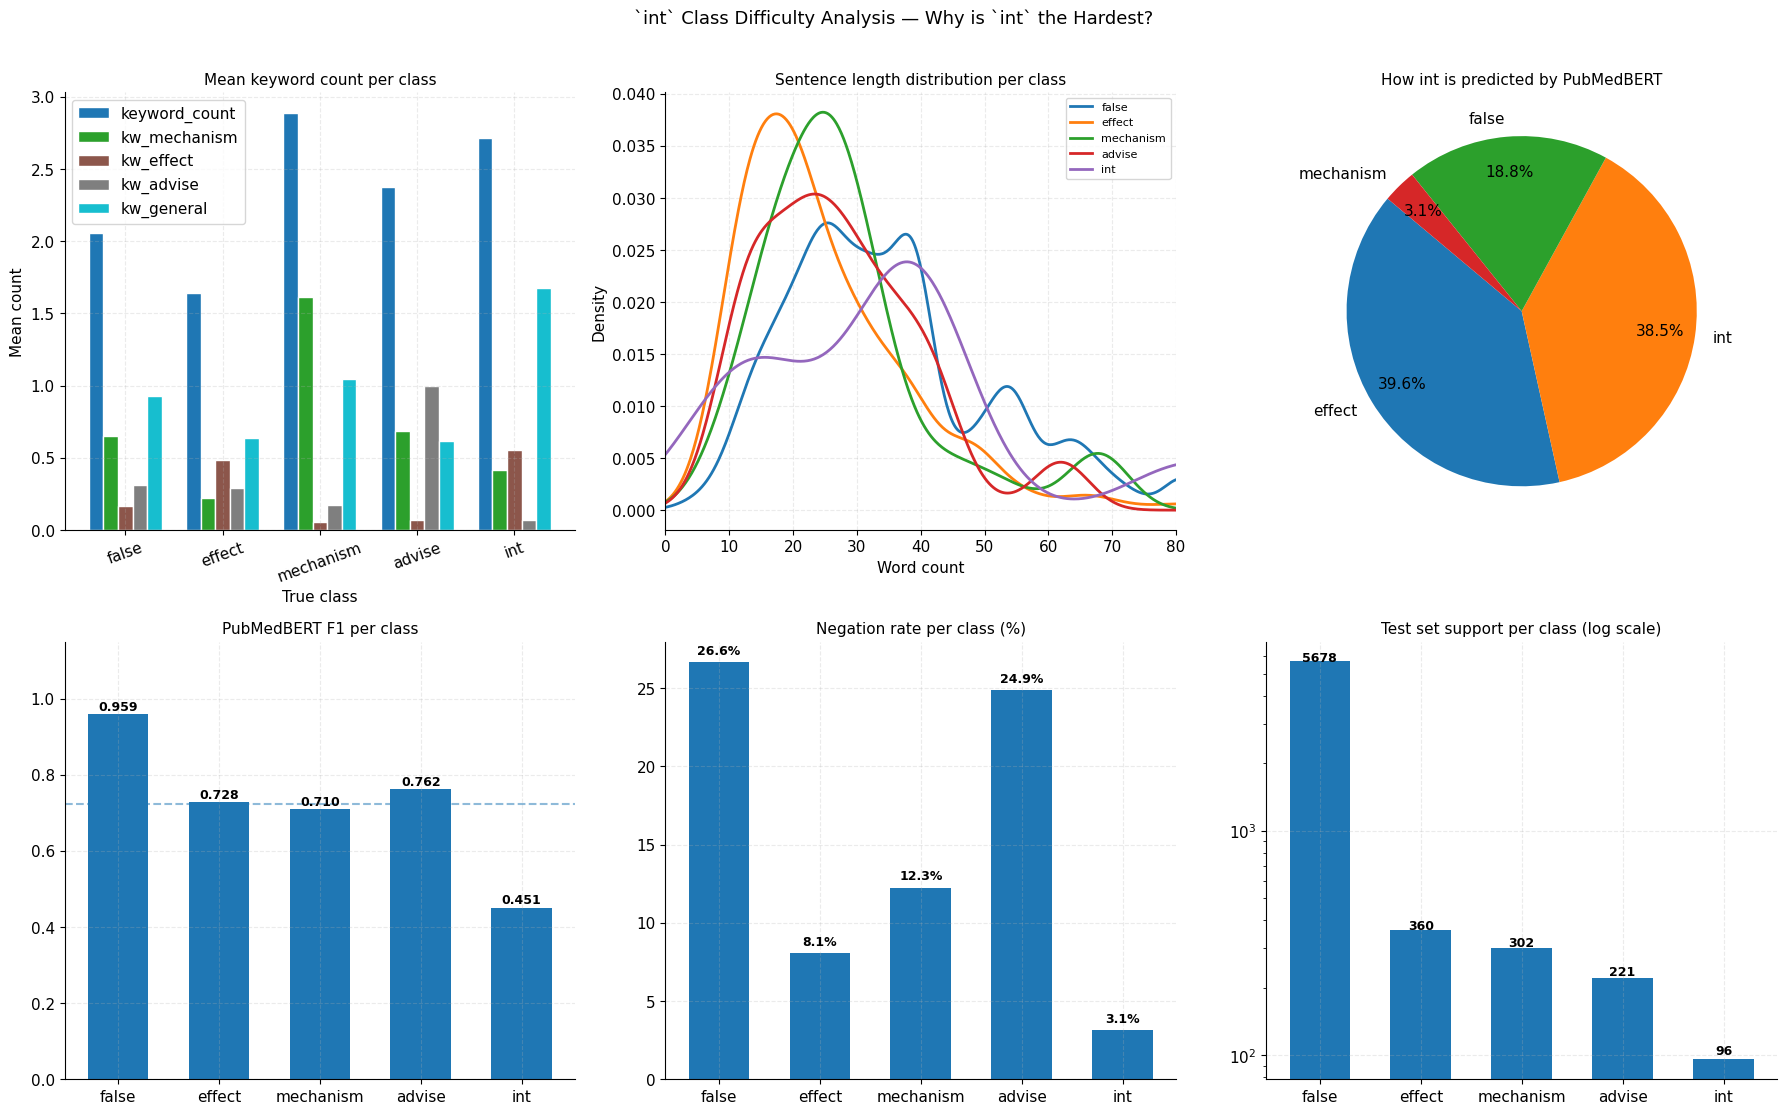

In [17]:
# Ensure required derived features exist
text_col = next(
    (c for c in ['sentence_cleaned','sentence_original','sentence_masked']
     if c in test_df.columns),
    None
)

text_series = (
    test_df[text_col].fillna('').astype(str).str.lower()
    if text_col else None
)

# Sentence length
if 'sentence_length' not in test_df.columns and text_series is not None:
    test_df['sentence_length'] = text_series.str.split().str.len()

# Keyword features
keyword_specs = {
    'kw_mechanism': ['inhibit','induce','metabolis','metaboliz','cyp','enzyme',
                     'clearance','absorption','bioavailability','excret','plasma','concentration','half-life','bind'],
    'kw_effect': ['bleeding','toxicity','adverse','sedation','hypotension',
                  'bradycardia','elevat','risk','prolong','danger','side'],
    'kw_advise': ['contraindicated','avoid','caution','monitor','warning','recommend','concomitant','concurrent'],
    'kw_general': ['interact','interaction','co-administration','combination','combined'],
}

for col, kws in keyword_specs.items():
    if col not in test_df.columns and text_series is not None:
        test_df[col] = text_series.apply(
            lambda s, kws=kws: sum(1 for kw in kws if kw in s)
        )

# Total keyword count
if 'keyword_count' not in test_df.columns:
    kw_cols = [c for c in keyword_specs if c in test_df.columns]
    test_df['keyword_count'] = (
        test_df[kw_cols].sum(axis=1) if kw_cols else 0
    )

# Negation feature
if 'has_negation' not in test_df.columns and text_series is not None:
    neg_words = {'not','no','without','neither','nor','never','none'}
    test_df['has_negation'] = text_series.apply(
        lambda s: int(any(w in s.split() for w in neg_words))
    )

# Multi-panel figure
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

fig.suptitle(
    '`int` Class Difficulty Analysis — Why is `int` the Hardest?',
    fontsize=13,
    y=1.01
)

kw_cols_present = [
    c for c in ['keyword_count','kw_mechanism','kw_effect','kw_advise','kw_general']
    if c in test_df.columns
]

# Panel 1: Keyword density
ax = axes[0, 0]
kw_means = (
    test_df.groupby('true_label')[kw_cols_present]
    .mean()
    .reindex(LABEL_ORDER)
    .fillna(0)
)

kw_means.plot(
    kind='bar',
    ax=ax,
    colormap='tab10',
    width=0.75,
    edgecolor='white'
)

ax.set_title('Mean keyword count per class', fontsize=11)
ax.set_xlabel('True class')
ax.set_ylabel('Mean count')
ax.tick_params(axis='x', rotation=20)

# Panel 2: Sentence length
ax = axes[0, 1]
if 'sentence_length' in test_df.columns:
    for lbl in LABEL_ORDER:
        sub = test_df[test_df['true_label'] == lbl]['sentence_length'].dropna()
        if len(sub):
            sub.plot.kde(ax=ax, label=lbl, linewidth=2)

    ax.set_title('Sentence length distribution per class', fontsize=11)
    ax.set_xlabel('Word count')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 80)
else:
    ax.axis('off')

# Panel 3: int prediction confusion
ax = axes[0, 2]
int_pred_counts = int_preds.value_counts()

ax.pie(
    int_pred_counts.values,
    labels=int_pred_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.8
)

ax.set_title(f'How int is predicted by {ATTN_MODEL_NAME}', fontsize=11)

# Panel 4: F1 scores
ax = axes[1, 0]
f1_per_class = [rep.get(lbl, {}).get('f1-score', 0) for lbl in LABEL_ORDER]

bars = ax.bar(LABEL_ORDER, f1_per_class, width=0.6)

for bar, val in zip(bars, f1_per_class):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{val:.3f}',
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

ax.axhline(
    np.mean(f1_per_class),
    linestyle='--',
    alpha=0.5
)

ax.set_title(f'{ATTN_MODEL_NAME} F1 per class', fontsize=11)
ax.set_ylim(0, 1.15)

# Panel 5: Negation rate
ax = axes[1, 1]
if 'has_negation' in test_df.columns:
    neg_rates = (
        test_df.groupby('true_label')['has_negation']
        .mean()
        .reindex(LABEL_ORDER) * 100
    )

    ax.bar(LABEL_ORDER, neg_rates.values, width=0.6)

    for i, val in enumerate(neg_rates.values):
        ax.text(i, val + 0.5, f'{val:.1f}%',
                ha='center', fontsize=9, fontweight='bold')

    ax.set_title('Negation rate per class (%)', fontsize=11)
else:
    ax.axis('off')

# Panel 6: Class support
ax = axes[1, 2]
support_counts = [int(rep.get(lbl, {}).get('support', 0)) for lbl in LABEL_ORDER]

bars = ax.bar(LABEL_ORDER, support_counts, width=0.6)

for bar, val in zip(bars, support_counts):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        str(val),
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

ax.set_title('Test set support per class (log scale)', fontsize=11)
ax.set_yscale('log')

plt.tight_layout()
save_fig('int_class_difficulty_analysis')

## Linguistic Analysis of the `int` Class

This section performs a qualitative error analysis of the *interaction (int)* class by inspecting correctly classified and misclassified examples.

The goal is to understand the linguistic properties that make `int` inherently difficult:

- **Correct examples** typically contain clear but *generic interaction cues* (e.g., “interact”, “combination”).
- **Misclassified examples** often overlap semantically with *mechanism* or *effect*, causing ambiguity.
- The `int` class lacks strong pharmacological anchors, unlike other classes (e.g., CYP enzymes, toxicity terms).
- It effectively acts as a *residual category*, assigned when no explicit subtype is present.
- This results in *fuzzy decision boundaries* and higher confusion rates.

Overall, this analysis explains why even strong transformer models struggle with `int`.

In [18]:
print('-'*70)
print('`int` Class Test Sentences Linguistic Examination')
print('-'*70)

# Filter interaction class samples
int_rows = test_df[test_df['true_label'] == 'int'].copy()

print(f'\nTotal int test sentences : {len(int_rows)}')
print(f'{ATTN_MODEL_NAME} correct : {int_rows["model_correct"].sum()} ({int_rows["model_correct"].mean()*100:.1f}%)')
print()

# Correct examples
print('--- Correctly classified `int` examples ---')

correct_int = int_rows[int_rows['model_correct'] == True]

for i, (_, row) in enumerate(correct_int.head(3).iterrows()):
    orig = str(row.get('sentence_original', row.get('sentence_masked','')))
    kw = str(row.get('keywords_found', ''))

    print(f'[{i+1}] {orig[:120]}')
    print(f'Keywords: {kw}  |  Pred: {row[pred_col]}')
    print()

# Misclassified examples
print('--- Misclassified `int` examples ---')

wrong_int = int_rows[int_rows['model_correct'] == False]

for i, (_, row) in enumerate(wrong_int.head(5).iterrows()):
    orig = str(row.get('sentence_original', row.get('sentence_masked','')))
    kw = str(row.get('keywords_found', ''))

    print(f'[{i+1}] True: int | Pred: {row[pred_col]}')
    print(f'{orig[:120]}')
    print(f'Keywords: {kw}')
    print()

# Interpretation
print('-'*70)
print(' INTERPRETATION')
print('-'*70)

print('1. `int` sentences rely on generic interaction language (e.g. "interact", "combination"),')
print('which lacks strong pharmacological specificity.')

print('2. There is significant lexical overlap with mechanism and effect classes,')
print('leading to systematic confusion between categories.')

print('3. The `int` class behaves as a residual label — used when no explicit')
print('mechanism, effect, or advice signal is present.')

print('4. This introduces inherently fuzzy decision boundaries, even for human annotation.')

print('5. Limited sample size further reduces the model’s ability to learn robust patterns.')

print('-'*70)

----------------------------------------------------------------------
`int` Class Test Sentences Linguistic Examination
----------------------------------------------------------------------

Total int test sentences : 96
PubMedBERT correct : 37 (38.5%)

--- Correctly classified `int` examples ---
[1] Some anticonvulsants may interact with Mephenytoin. 
Keywords: interact  |  Pred: int

[2] Mequitazine can interact with CNS depressant, antichlolinergic, TCA, MAOIs, and alcohol.
Keywords: interact  |  Pred: int

[3] Mequitazine can interact with CNS depressant, antichlolinergic, TCA, MAOIs, and alcohol.
Keywords: interact  |  Pred: int

--- Misclassified `int` examples ---
[1] True: int | Pred: false
Melatonin may interact with the following drugs: aspirin and other NSAIDs (may lower melatonin levels), fluvoxamine (bio
Keywords: inhibit, bioavailability, adverse, sedation, increase, decrease, lower, block, interact, level

[2] True: int | Pred: false
Melatonin may interact with the fol

## Saved Outputs Summary

This section lists all generated artefacts from the analysis phase, including visualisations and computed metrics. These files are organised into dedicated directories for reproducibility and report integration.

In [19]:
for d, label in [(ANALYSIS_PLOTS_DIR, 'Plots'), (ANALYSIS_METRICS_DIR, 'Metrics')]:
    print('')
    for f in sorted(d.iterdir()):
        if f.is_file():
            print('')
    print()


## Summary of Findings

The analysis highlights several key insights into model behaviour and limitations. Transformer models generally attend to pharmacologically meaningful tokens, particularly for well-defined classes such as *mechanism* and *advise*, indicating strong alignment with domain-relevant features. However, errors are systematic rather than random, with most failures arising from negation handling, long-range dependencies, and semantic ambiguity between closely related classes.

In terms of generalisation, transformer models consistently outperform classical and rule-based approaches, but their performance varies across corpus sources, suggesting sensitivity to domain differences. The `int` class emerges as the most challenging due to its lack of distinctive lexical signals, high semantic overlap with other classes, its role as a residual category, and limited training support. 

Linguistic feature analysis further confirms that class separability is strongly influenced by keyword presence, sentence complexity, and negation patterns. Overall, while transformer models achieve strong performance, the findings emphasise that data characteristics and annotation design play a critical role in determining model success, highlighting the need for improved handling of ambiguity, richer representations, and more balanced datasets.